<a href="https://colab.research.google.com/github/smminhaz/SkillMorph/blob/ML/Day_5_Matplotlib%26Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Core stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sensible global defaults so every plot looks consistent
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi']     = 100

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATA_DIR = '/content/drive/MyDrive/DataSets'

students = pd.read_csv(f'{DATA_DIR}/StudentsPerformance/StudentsPerformance.csv')
gym      = pd.read_csv(f'{DATA_DIR}/gym_membership/gym_membership.csv')

print(f'students: {students.shape}   gym: {gym.shape}')

students: (1000, 8)   gym: (1000, 17)


In [6]:
students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
students.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


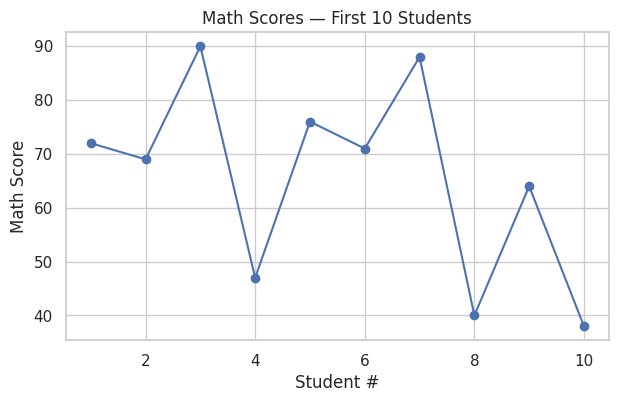

In [9]:
# Line plots are for *ordered* data (time, index, sequence).
# Here: math scores of the first 10 students.
scores = students['math score'].head(10)

fig, ax = plt.subplots()
ax.plot(range(1, 11), scores, marker='o')
ax.set(title='Math Scores — First 10 Students',
       xlabel='Student #', ylabel='Math Score')
plt.show()

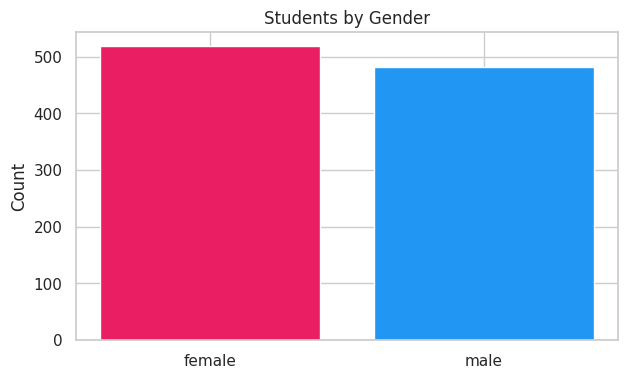

In [10]:
# Count students by gender, plot as a bar chart.
gender_count = students['gender'].value_counts()

fig, ax = plt.subplots()
ax.bar(gender_count.index, gender_count.values, color=['#e91e63', '#2196f3'])
ax.set(title='Students by Gender', ylabel='Count')
plt.show()

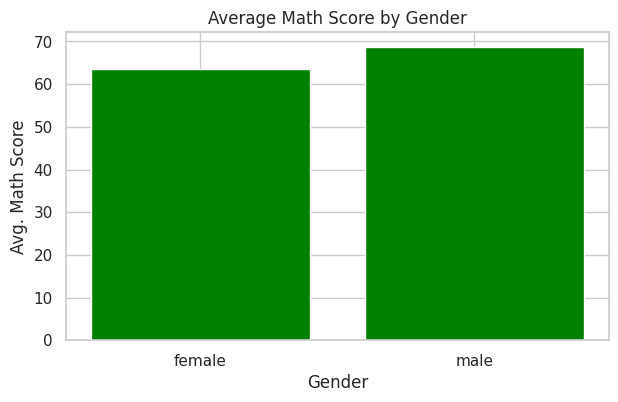

In [11]:
# Aggregated bar: average math score per gender.
avg_math = students.groupby('gender')['math score'].mean()

fig, ax = plt.subplots()
ax.bar(avg_math.index, avg_math.values, color='green')
ax.set(title='Average Math Score by Gender',
       xlabel='Gender', ylabel='Avg. Math Score')
plt.show()

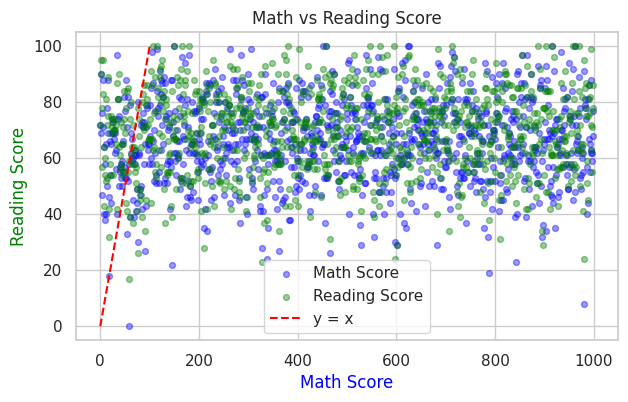

In [12]:
# Does reading ability track math ability? Scatter tells you at a glance.
fig, ax = plt.subplots()
ax.scatter(range(len(students)), students['math score'],
           color='blue', label='Math Score', alpha=0.4, s=18)
# Reading scores (red)
ax.scatter(range(len(students)), students['reading score'],
           color='green', label='Reading Score', alpha=0.4, s=18)

# Perfect diagonal line (y = x)
ax.plot([0, 100], [0, 100], color='red', linestyle='--', label='y = x')

ax.set(title='Math vs Reading Score')
ax.set_xlabel('Math Score', color= 'blue')
ax.set_ylabel('Reading Score', color='green')
ax.legend()
plt.show()

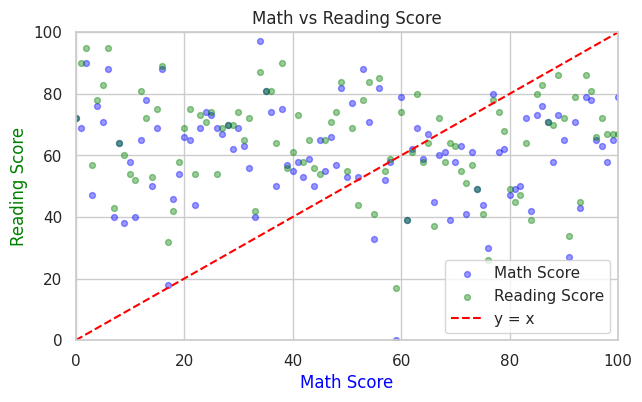

In [13]:
# Does reading ability track math ability? Scatter tells you at a glance.
fig, ax = plt.subplots()
ax.scatter(range(len(students)), students['math score'],
           color='blue', label='Math Score', alpha=0.4, s=18)
# Reading scores (red)
ax.scatter(range(len(students)), students['reading score'],
           color='green', label='Reading Score', alpha=0.4, s=18)
# Perfect diagonal line (y = x)
ax.plot([0, 100], [0, 100], color='red', linestyle='--', label='y = x')
ax.set(title='Math vs Reading Score')
ax.set_xlabel('Math Score', color= 'blue')
ax.set_ylabel('Reading Score', color='green')
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.show()

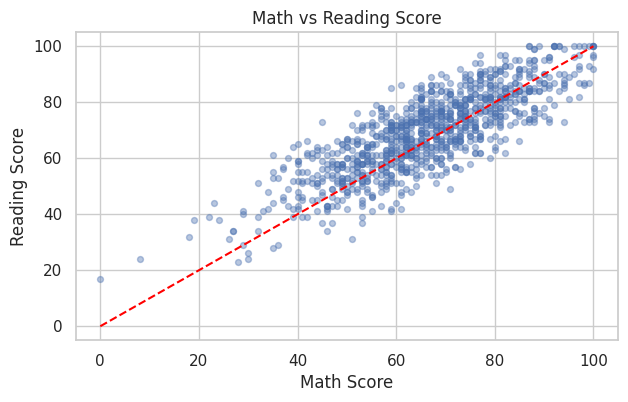

In [14]:
# Does reading ability track math ability? Scatter tells you at a glance.
fig, ax = plt.subplots()
ax.scatter(students['math score'], students['reading score'],
           alpha=0.4, s=18)
# Perfect diagonal line (y = x)
ax.plot([0, 100], [0, 100], color='red', linestyle='--', label='y = x')
ax.set(title='Math vs Reading Score',
       xlabel='Math Score', ylabel='Reading Score')
plt.show()

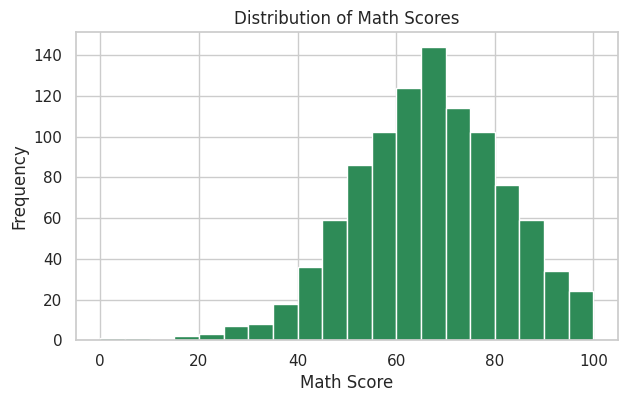

In [15]:
fig, ax = plt.subplots()
ax.hist(students['math score'], bins=20, color='seagreen', edgecolor='white')
ax.set(title='Distribution of Math Scores',
       xlabel='Math Score', ylabel='Frequency')
plt.show()

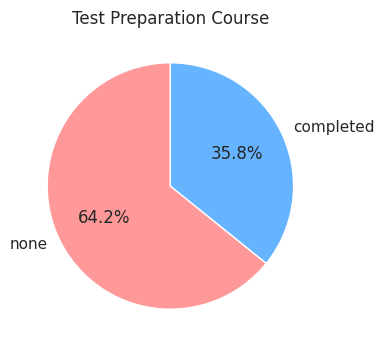

In [16]:
prep = students['test preparation course'].value_counts()

fig, ax = plt.subplots()
ax.pie(prep.values, labels=prep.index, autopct='%1.1f%%',
       colors=['#ff9999', '#66b3ff'], startangle=90)
ax.set_title('Test Preparation Course')
plt.show()

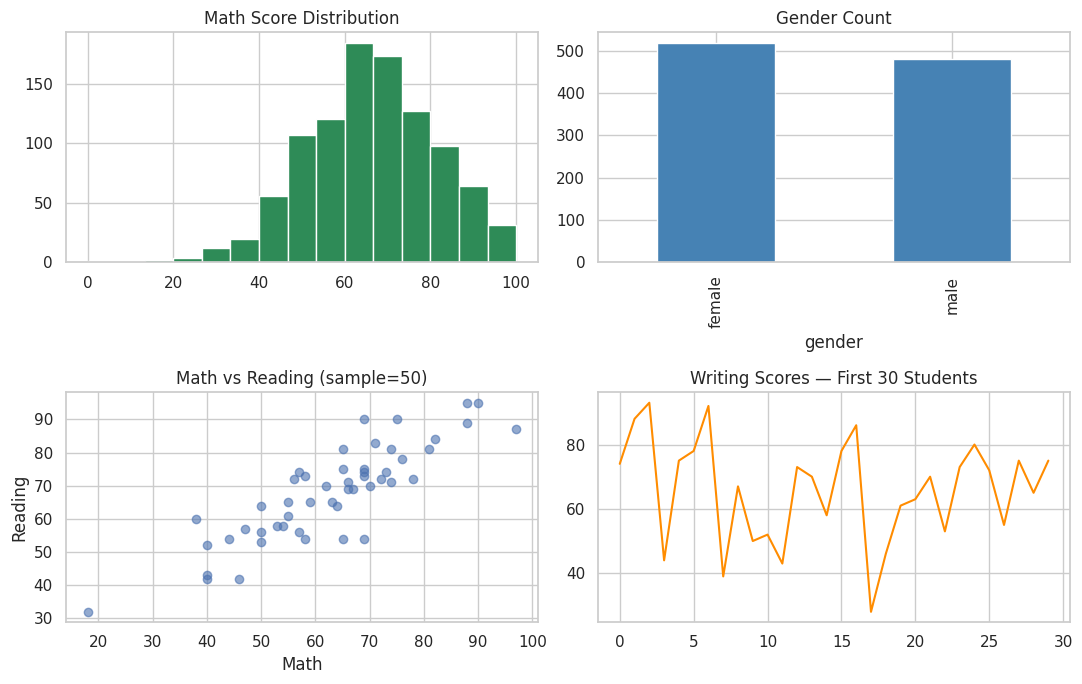

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].hist(students['math score'], bins=15, color='seagreen')
axes[0, 0].set_title('Math Score Distribution')

students['gender'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Gender Count')

axes[1, 0].scatter(students['math score'].head(50),
                   students['reading score'].head(50), alpha=0.6)
axes[1, 0].set(title='Math vs Reading (sample=50)',
               xlabel='Math', ylabel='Reading')

axes[1, 1].plot(students['writing score'].head(30), color='darkorange')
axes[1, 1].set_title('Writing Scores — First 30 Students')

plt.tight_layout()
plt.show()

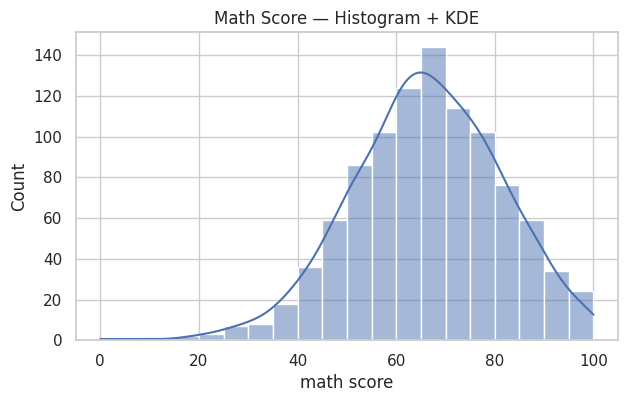

In [18]:
fig, ax = plt.subplots()
sns.histplot(students['math score'], bins=20, kde=True, ax=ax)
ax.set_title('Math Score — Histogram + KDE')
plt.show()

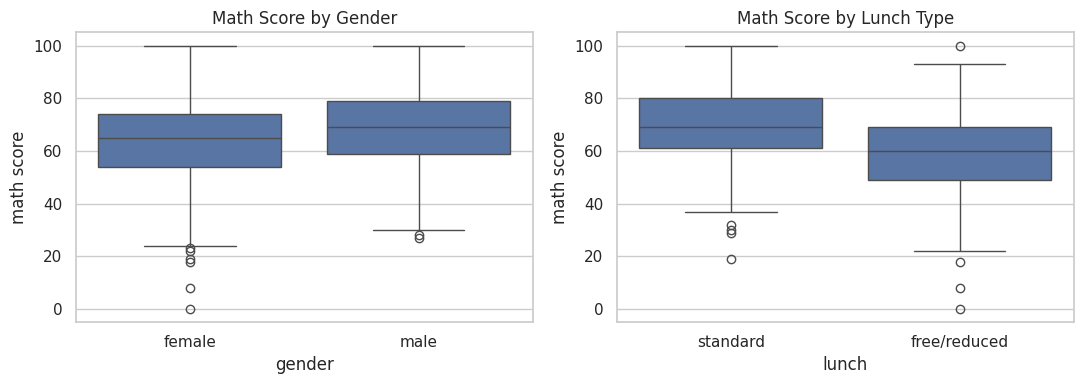

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=students, x='gender', y='math score', ax=axes[0])
axes[0].set_title('Math Score by Gender')

sns.boxplot(data=students, x='lunch', y='math score', ax=axes[1])
axes[1].set_title('Math Score by Lunch Type')

plt.tight_layout()
plt.show()

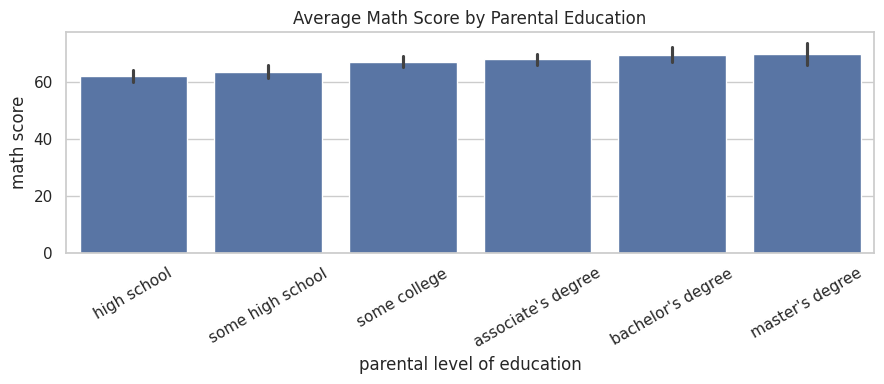

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
order = students.groupby('parental level of education')['math score'].mean().sort_values().index
sns.barplot(data=students, x='parental level of education',
            y='math score', order=order, ax=ax)
ax.set_title('Average Math Score by Parental Education')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

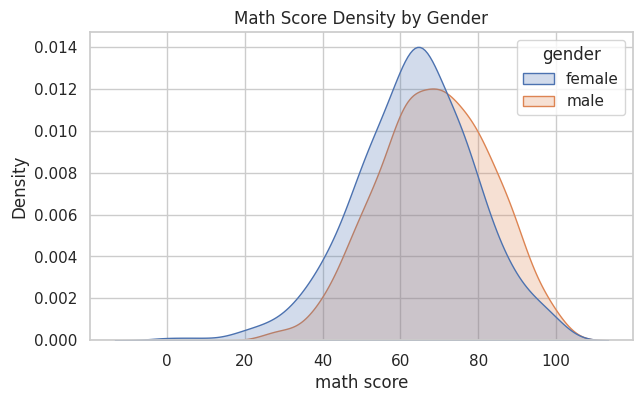

In [21]:
fig, ax = plt.subplots()
sns.kdeplot(data=students, x='math score', hue='gender', fill=True, ax=ax)
ax.set_title('Math Score Density by Gender')
plt.show()

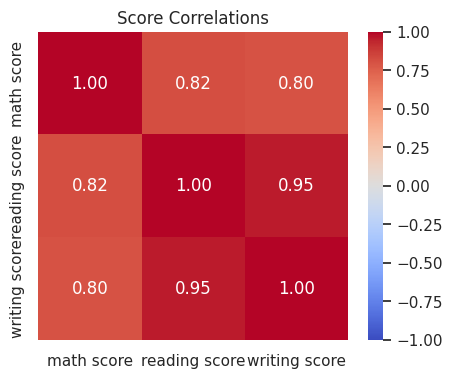

In [22]:
corr = students[['math score', 'reading score', 'writing score']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', ax=ax)
ax.set_title('Score Correlations')
plt.show()

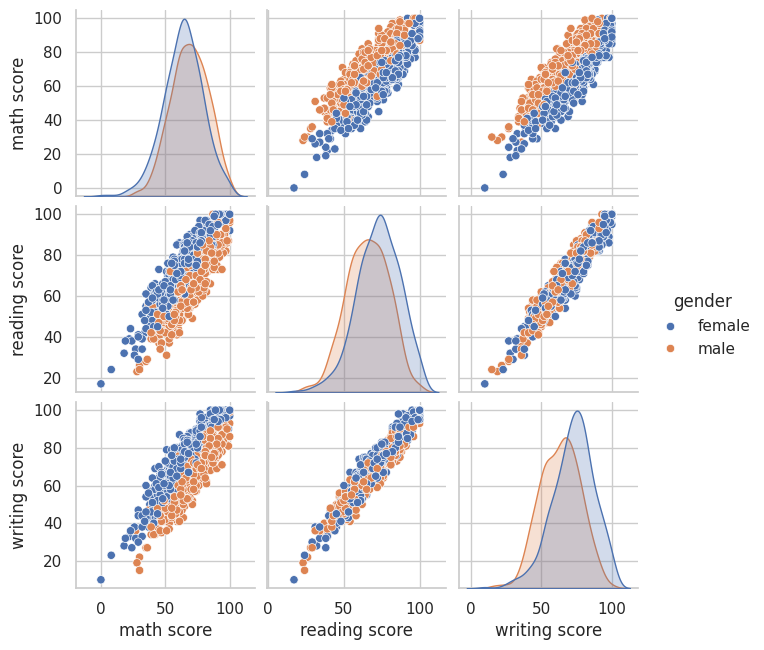

In [23]:
sns.pairplot(students[['math score', 'reading score', 'writing score', 'gender']],
             hue='gender', height=2.2)
plt.show()

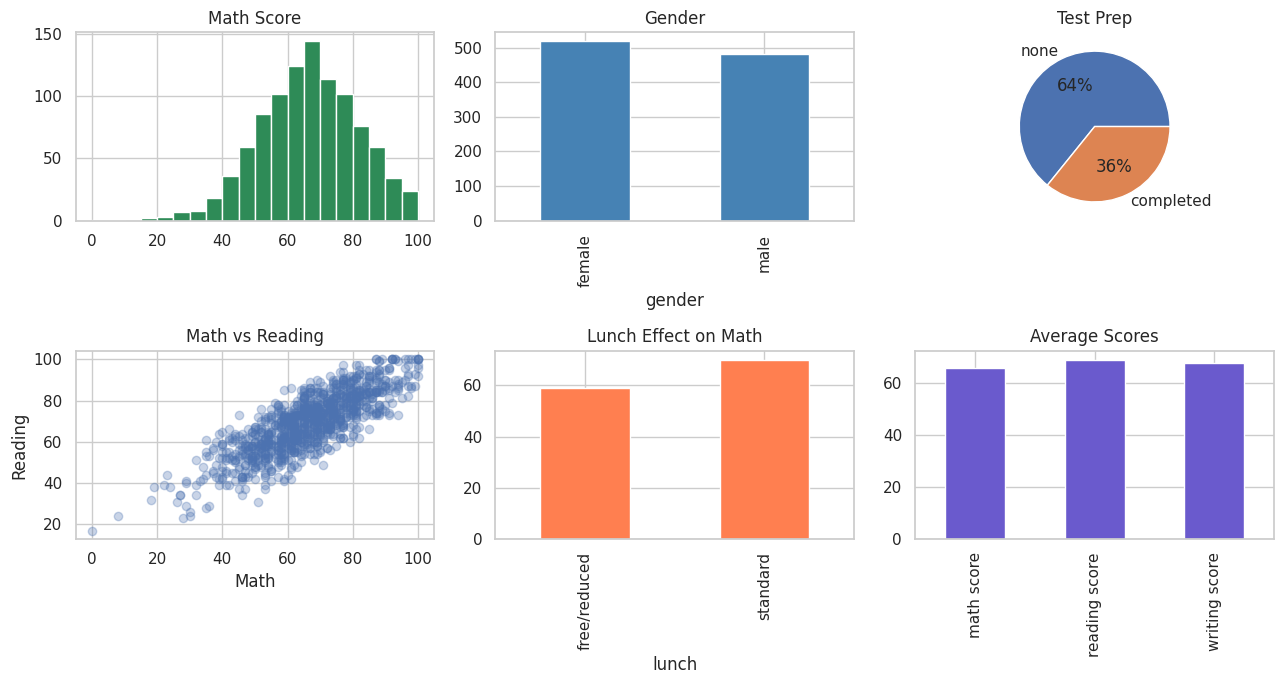

In [25]:
def quick_eda(df):
    """Six-panel EDA summary for the students dataframe."""
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))

    axes[0, 0].hist(df['math score'], bins=20, color='seagreen')
    axes[0, 0].set_title('Math Score')

    df['gender'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
    axes[0, 1].set_title('Gender')

    prep = df['test preparation course'].value_counts()
    axes[0, 2].pie(prep.values, labels=prep.index, autopct='%1.0f%%')
    axes[0, 2].set_title('Test Prep')

    axes[1, 0].scatter(df['math score'], df['reading score'], alpha=0.3)
    axes[1, 0].set(title='Math vs Reading', xlabel='Math', ylabel='Reading')

    df.groupby('lunch')['math score'].mean().plot(kind='bar', ax=axes[1, 1], color='coral')
    axes[1, 1].set_title('Lunch Effect on Math')

    df[['math score', 'reading score', 'writing score']].mean().plot(
        kind='bar', ax=axes[1, 2], color='slateblue')
    axes[1, 2].set_title('Average Scores')

    plt.tight_layout()
    plt.show()

quick_eda(students)

In [26]:
gym.head()

,id,gender,birthday,Age,abonoment_type,visit_per_week,days_per_week,attend_group_lesson,fav_group_lesson,avg_time_check_in,avg_time_check_out,avg_time_in_gym,drink_abo,fav_drink,personal_training,name_personal_trainer,uses_sauna
0,1,Female,4/18/1997,27,Premium,4,"Mon, Sat, Tue, Wed",True,"Kickboxen, BodyPump, Zumba",19:31:00,21:27:00,116,False,NaN,False,NaN,True
1,2,Female,9/18/1977,47,Standard,3,"Mon, Sat, Wed",False,NaN,19:31:00,20:19:00,48,False,NaN,True,Chantal,False
2,3,Male,3/30/1983,41,Premium,1,Sat,True,XCore,8:29:00,10:32:00,123,True,"berry_boost, lemon",True,Mike,False
3,4,Male,4/12/1980,44,Premium,3,"Sat, Tue, Wed",False,NaN,9:54:00,11:33:00,99,True,passion_fruit,True,Mike,True
4,5,Male,9/10/1980,44,Standard,2,"Thu, Wed",True,"Running, Yoga, Zumba",8:29:00,9:19:00,50,False,NaN,True,Mike,False


In [27]:
print('Shape   :', gym.shape)
print('Columns :', gym.columns.tolist())
gym.dtypes

Shape   : (1000, 17)
Columns : ['id', 'gender', 'birthday', 'Age', 'abonoment_type', 'visit_per_week', 'days_per_week', 'attend_group_lesson', 'fav_group_lesson', 'avg_time_check_in', 'avg_time_check_out', 'avg_time_in_gym', 'drink_abo', 'fav_drink', 'personal_training', 'name_personal_trainer', 'uses_sauna']


,0
id,int64
gender,object
birthday,object
Age,int64
abonoment_type,object
visit_per_week,int64
days_per_week,object
attend_group_lesson,bool
fav_group_lesson,object
avg_time_check_in,object


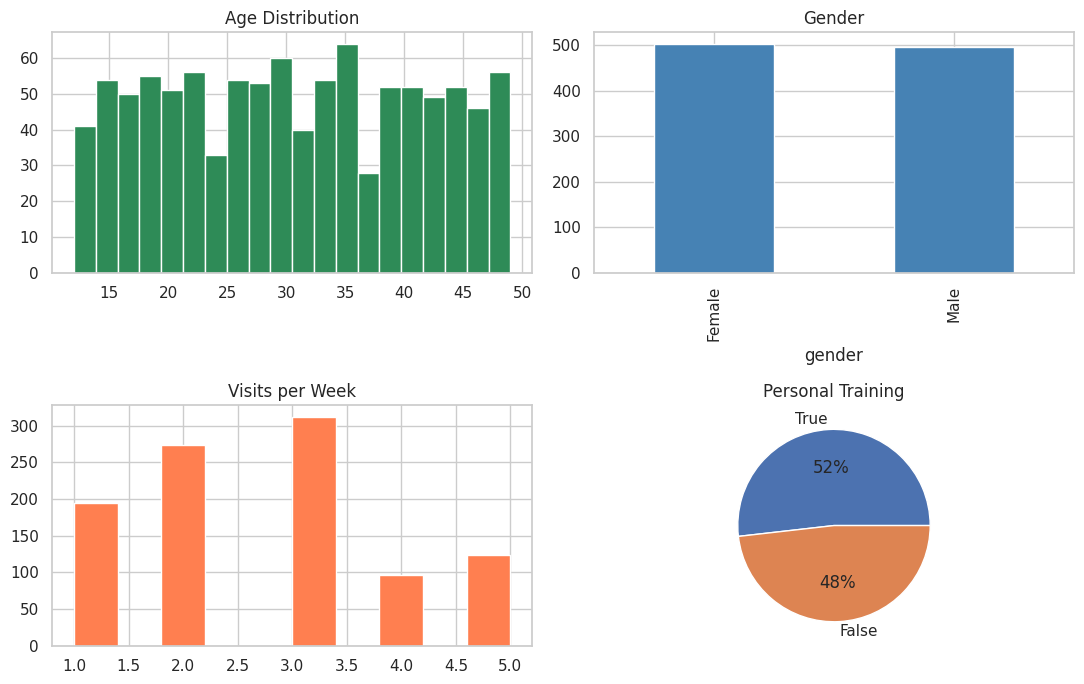

In [28]:
# 4-panel snapshot of the gym data
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].hist(gym['Age'], bins=20, color='seagreen')
axes[0, 0].set_title('Age Distribution')

gym['gender'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Gender')

axes[1, 0].hist(gym['visit_per_week'], bins=10, color='coral')
axes[1, 0].set_title('Visits per Week')

gym['personal_training'].value_counts().plot(
    kind='pie', ax=axes[1, 1], autopct='%1.0f%%', ylabel='')
axes[1, 1].set_title('Personal Training')

plt.tight_layout()
plt.show()